# 📊 ATR Breakout + Chandelier Exit Strategy

## 🔹 Overview
This project implements and backtests an **ATR-based breakout trading strategy** with a **Chandelier Exit** stop-loss mechanism.  
The system uses volatility (measured by **Average True Range, ATR**) both to confirm breakouts and to manage exits.  

The strategy is designed to capture strong **trend-following moves**, while avoiding noise through ATR-based filters.

---

## 🔹 Technical Background

### Average True Range (ATR)
ATR measures market volatility based on the True Range (TR):

\[
TR_t = \max\{ High_t - Low_t, |High_t - Close_{t-1}|, |Low_t - Close_{t-1}| \}
\]

ATR is the exponentially smoothed moving average of TR over *n* periods:

\[
ATR_t = EMA_n(TR_t)
\]

### Chandelier Exit
A trailing stop-loss designed by Chuck LeBeau:

\[
Stop_t = H_{sinceEntry} - K \times ATR_t
\]

Where:
- \( H_{sinceEntry} \) = highest high since trade entry  
- \( K \) = multiplier (commonly 3×ATR)  

---

## 🔹 Strategy Rules

1. **Entry Rule (Long-only):**  
   - Buy when **Close > Previous N-bar High + ATR Filter × ATR**  
   - Example: 20-day breakout above the highest high plus 0.5 × ATR.  

2. **Exit Rule (Chandelier Exit):**  
   - Exit when **Close < (Highest High Since Entry − K × ATR)**  

3. **Transaction Costs:**  
   - A fixed cost (e.g., 5 bps) is applied on each entry and exit.  

---

## 🔹 Backtest Framework
The backtest calculates:  
- **Equity Curves:** Strategy vs Buy & Hold.  
- **Relative Performance Ratio:** Strategy ÷ Buy & Hold.  
- **Performance Metrics:**  
  - **CAGR (Compound Annual Growth Rate):**
    \[
    CAGR = \left(\frac{V_{end}}{V_{start}}\right)^{1/T_{years}} - 1
    \]
  - **Sharpe Ratio:**
    \[
    Sharpe = \frac{E[R - R_f]}{\sigma_R} \times \sqrt{252}
    \]
  - **Max Drawdown (MDD):**
    \[
    MDD = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}
    \]

---

## 🔹 Implementation Flow
```python
# 1. Load synthetic OHLCV data
df = load_synthetic()

# 2. Compute ATR (Wilder smoothing)
df = add_atr(df)

# 3. Apply breakout + chandelier strategy
df = atr_breakout_chandelier(df)

# 4. Backtest: equity curves, trades, metrics


In [1]:
print("Hello, World!")

Hello, World!


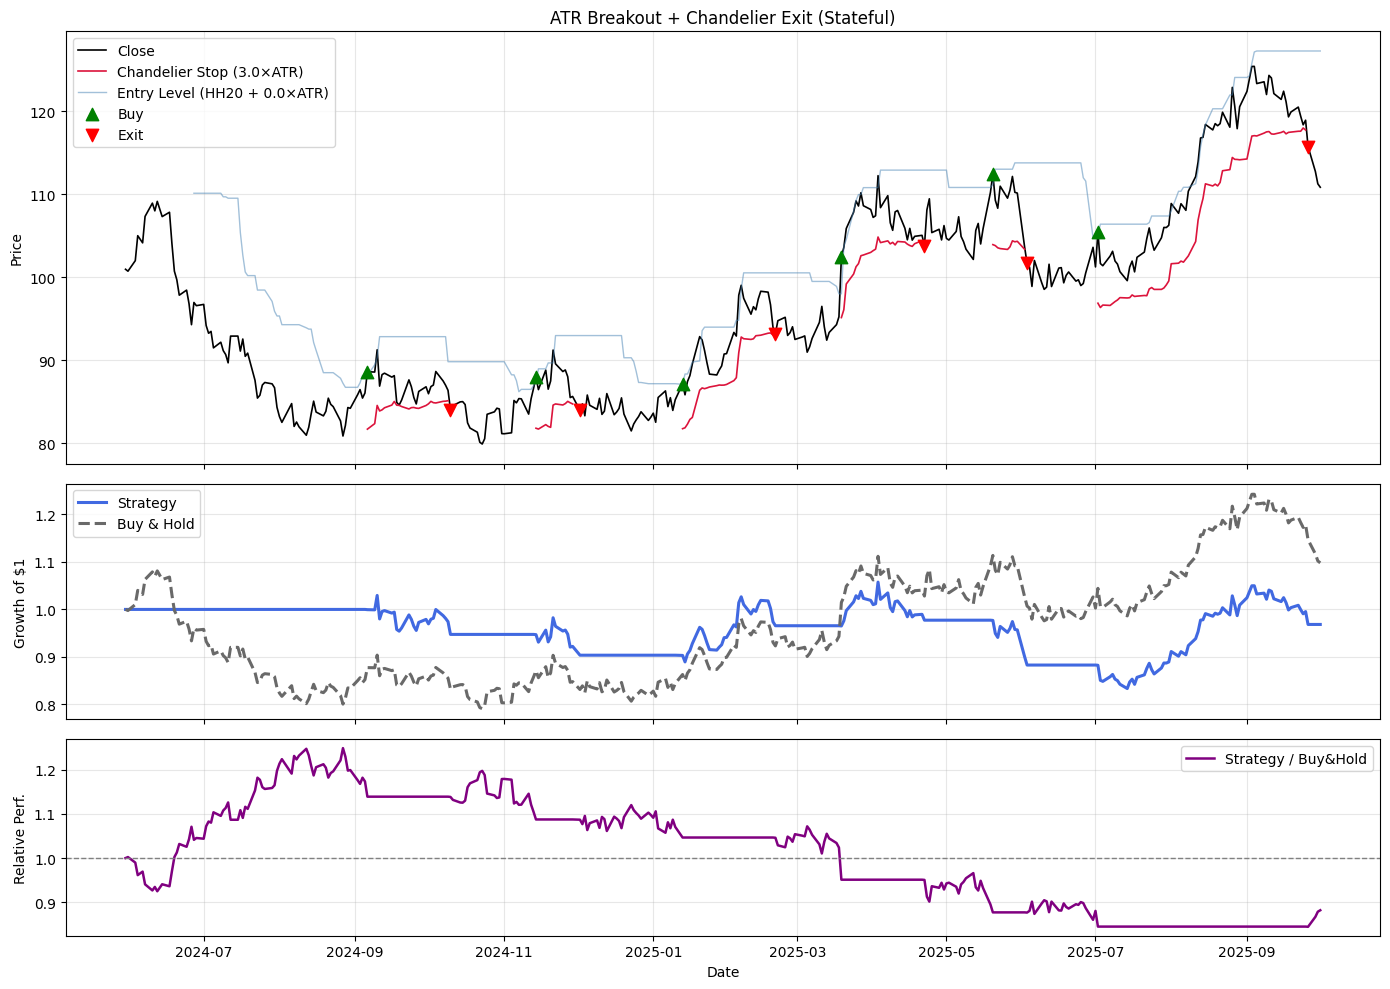

=== ATR Breakout + Chandelier Exit Results ===
CAGR Strategy  : -2.37%
CAGR Buy&Hold  : 7.22%
Sharpe (Strat) : -0.03
Max DD (Strat) : -21.17%
Trades: Entries=6, Exits=6
Final Ratio (Strategy/Buy&Hold): 0.882


In [ ]:
# ==== ATR Breakout Strategy with Chandelier Exit ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
N_BARS      = 350         # number of business bars in synthetic series
ATR_LEN     = 14          # Wilder ATR length
ENTRY_N     = 20          # breakout lookback (previous N-bar high)
ENTRY_F     = 0.0         # ATR filter added to breakout (e.g., 0.5 -> need +0.5*ATR above prev high)
EXIT_K      = 3.0         # Chandelier exit multiple (highest high since entry - K*ATR)
COST_PCT    = 0.0005      # 5 bps each entry/exit (set 0 for none)
SEED        = 42
# ---------------------------------------

# --------------- Synthetic OHLCV ---------------
def load_synthetic(n=N_BARS, seed=SEED):
    np.random.seed(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.12, 0.30, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    # build a plausible high/low around close
    spread = np.random.uniform(0.003, 0.02, size=n)
    high = close * (1 + spread)
    low  = close * (1 - spread)
    open_ = close.shift(1).fillna(close.iloc[0])  # simple synthetic open
    vol = pd.Series(np.random.randint(8e5, 4e6, size=n), index=dates, name="Volume")
    df = pd.DataFrame({"Open": open_, "High": high, "Low": low, "Close": close, "Volume": vol})
    return df

# --------------- ATR (Wilder) ---------------
def add_atr(df, n=ATR_LEN):
    df = df.copy()
    prev_close = df["Close"].shift(1)
    tr = pd.concat([
        (df["High"] - df["Low"]),
        (df["High"] - prev_close).abs(),
        (df["Low"]  - prev_close).abs()
    ], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/n, adjust=False).mean()  # Wilder smoothing
    df["TR"]  = tr
    df["ATR"] = atr
    return df

# --------------- Strategy (state machine) ---------------
def atr_breakout_chandelier(df,
                            entry_n=ENTRY_N,
                            atr_filter=ENTRY_F,
                            exit_k=EXIT_K,
                            cost_pct=COST_PCT):
    """
    Entry:  Close > previous N-bar High + atr_filter*ATR
    Exit :  Close < (highest high since entry - exit_k*ATR)  (Chandelier Exit)
    Long-only, stateful; applies costs on entry and exit bars.
    """
    df = df.copy()
    # precompute levels
    prev_n_high = df["High"].rolling(entry_n).max().shift(1)  # yesterday's N-bar high
    df["EntryLvl"] = prev_n_high + atr_filter * df["ATR"]

    position = 0
    highest_high_since_entry = np.nan
    trail_stop_series = []
    trades = []   # +1 entry, -1 exit, 0 none
    positions = []

    for i, (idx, row) in enumerate(df.iterrows()):
        close_i = row["Close"]
        high_i  = row["High"]
        atr_i   = row["ATR"]
        entry_lvl = row["EntryLvl"]

        trade = 0

        if position == 0:
            # only consider entry if ATR & entry level are defined
            if not np.isnan(entry_lvl) and not np.isnan(atr_i):
                if close_i > entry_lvl:
                    position = 1
                    highest_high_since_entry = high_i
                    trade = +1
                    trail = highest_high_since_entry - exit_k * atr_i
                else:
                    trail = np.nan
            else:
                trail = np.nan
        else:
            # update highest high while in trade
            if high_i > highest_high_since_entry:
                highest_high_since_entry = high_i
            trail = highest_high_since_entry - exit_k * atr_i if not np.isnan(atr_i) else np.nan

            # exit if close falls below trail
            if not np.isnan(trail) and close_i < trail:
                position = 0
                trade = -1
                highest_high_since_entry = np.nan
                trail = np.nan  # reset

        trades.append(trade)
        positions.append(position)
        trail_stop_series.append(trail)

    df["Position"] = positions
    df["Trade"]    = trades
    df["Trail"]    = pd.Series(trail_stop_series, index=df.index)

    # returns (first bar = 0)
    df["Ret"] = df["Close"].pct_change().fillna(0.0)
    gross = df["Position"].shift(1).fillna(0.0) * df["Ret"]

    # transaction costs on trade bars (entry & exit)
    costs = np.where(df["Trade"] != 0, cost_pct, 0.0)
    df["Strat_Ret"] = gross - costs

    # equity curves (start at 1)
    df["Equity_BuyHold"]  = (1.0 + df["Ret"]).cumprod()
    df["Equity_Strategy"] = (1.0 + df["Strat_Ret"]).cumprod()
    df["Eq_Ratio"]        = df["Equity_Strategy"] / df["Equity_BuyHold"]

    return df

# --------------- Metrics ---------------
def CAGR(series):
    years = (series.index[-1] - series.index[0]).days / 365
    return (series.iloc[-1]/series.iloc[0])**(1/years) - 1 if years > 0 else float("nan")

def sharpe(returns, rf=0.0):
    s = returns.std()
    return ((returns.mean() - rf)/s)*np.sqrt(252) if s and not np.isnan(s) else float("nan")

def max_drawdown(series):
    roll_max = series.cummax()
    dd = (series - roll_max)/roll_max
    return dd.min()

# --------------- Run ---------------
df = load_synthetic()
df = add_atr(df)

# align start to when ATR exists
first_ok = df["ATR"].first_valid_index()
df = df.loc[first_ok:].copy()

df = atr_breakout_chandelier(df)

# --------------- Plots ---------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={'height_ratios':[2.2,1.2,1.0]})

# Price + entries/exits + trail
ax1 = axes[0]
ax1.plot(df.index, df["Close"], color="black", lw=1.2, label="Close")
ax1.plot(df.index, df["Trail"], color="crimson", lw=1.2, label=f"Chandelier Stop ({EXIT_K}×ATR)")
# show entry level (optional, semi-transparent)
ax1.plot(df.index, df["EntryLvl"], color="steelblue", lw=1.0, alpha=0.5, label=f"Entry Level (HH{ENTRY_N} + {ENTRY_F}×ATR)")

buys  = df.index[df["Trade"] == +1]
exits = df.index[df["Trade"] == -1]
ax1.scatter(buys,  df.loc[buys, "Close"], marker="^", color="green", s=80, label="Buy",  zorder=5)
ax1.scatter(exits, df.loc[exits,"Close"], marker="v", color="red",   s=80, label="Exit", zorder=5)

ax1.set_title("ATR Breakout + Chandelier Exit (Stateful)")
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="best")

# Equity curves
ax2 = axes[1]
ax2.plot(df.index, df["Equity_Strategy"], color="royalblue", lw=2.2, label="Strategy")
ax2.plot(df.index, df["Equity_BuyHold"],  color="dimgray",   lw=2.2, ls="--", label="Buy & Hold")
ax2.set_ylabel("Growth of $1")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Relative performance
ax3 = axes[2]
ax3.plot(df.index, df["Eq_Ratio"], color="purple", lw=1.8, label="Strategy / Buy&Hold")
ax3.axhline(1.0, color="gray", lw=1, ls="--")
ax3.set_ylabel("Relative Perf.")
ax3.set_xlabel("Date")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# --------------- Report ---------------
print("=== ATR Breakout + Chandelier Exit Results ===")
print(f"CAGR Strategy  : {CAGR(df['Equity_Strategy']):.2%}")
print(f"CAGR Buy&Hold  : {CAGR(df['Equity_BuyHold']):.2%}")
print(f"Sharpe (Strat) : {sharpe(df['Strat_Ret']):.2f}")
print(f"Max DD (Strat) : {max_drawdown(df['Equity_Strategy']):.2%}")
print(f"Trades: Entries={int((df['Trade']==1).sum())}, Exits={int((df['Trade']==-1).sum())}")
print(f"Final Ratio (Strategy/Buy&Hold): {df['Eq_Ratio'].iloc[-1]:.3f}")
